In [ ]:
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load the dataset (Replace 'your_dataset.csv' with your actual file)
df = pd.read_csv('/content/Crash_Reporting_-_Incidents_Data.csv')

# Display first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())


<ipython-input-2-038846043ed3>:2: DtypeWarning: Columns (9,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Crash_Reporting_-_Incidents_Data.csv')


First few rows of the dataset:
  Report Number Local Case Number                Agency Name  \
0   MCP1123002M         190010046   Montgomery County Police   
1   MCP21610009          16028039   Montgomery County Police   
2   MCP2790000P          15041420                 MONTGOMERY   
3   MCP3378000J         230051006   Montgomery County Police   
4    DD5659000H         230049130  Rockville Police Departme   

        ACRS Report Type         Crash Date/Time Hit/Run        Route Type  \
0           Injury Crash  03/04/2019 08:41:00 AM      No  Maryland (State)   
1  Property Damage Crash  06/04/2016 07:14:00 PM     Yes            County   
2  Property Damage Crash  08/18/2015 11:00:00 PM      No            County   
3           Injury Crash  08/24/2023 07:46:00 AM      No  Maryland (State)   
4  Property Damage Crash  08/12/2023 04:28:00 PM     Yes               NaN   

  Lane Direction Lane Type Number of Lanes  ... First Harmful Event  \
0           West       NaN               2  

In [ ]:
# Drop columns that are not necessary
df = df.drop(columns=['Report Number', 'Local Case Number', 'Agency Name', 'Crash Date/Time', 'Location', 'Latitude', 'Longitude'])


In [ ]:
# Define a function to categorize severity based on the Collision Type
def derive_severity(row):
    if row['Collision Type'] in ['REAR END', 'HEAD ON', 'SIDESWIPE SAME DIRECTION', 'SIDESWIPE OPPOSITE DIRECTION']:
        return 'Severe'
    elif row['Collision Type'] in ['PARKED VEHICLE', 'SINGLE VEHICLE']:
        return 'Minor'
    else:
        return 'Moderate'

# Apply the function to derive the 'Severity of Accident' column
df['Severity of Accident'] = df.apply(derive_severity, axis=1)

# Drop the 'Collision Type' column as it is now represented by 'Severity of Accident'
df = df.drop(columns=['Collision Type'])


In [ ]:
# Handle missing values (if any)
df.fillna('Unknown', inplace=True)


<ipython-input-5-0f52d22e3794>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('Unknown', inplace=True)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert all entries in object columns to strings to ensure uniform data type
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].astype(str)

# Convert categorical variables to numerical using Label Encoding
label_encoders = {}
for column in df.columns:
    if df[column].dtype == 'object':
        label_encoders[column] = LabelEncoder()
        df[column] = label_encoders[column].fit_transform(df[column])



In [ ]:
# Define the target variable and features
X = df.drop('Severity of Accident', axis=1)
y = df['Severity of Accident']


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Model Accuracy: 94.55%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4866
           1       0.95      0.98      0.97     25775
           2       0.19      0.01      0.02       613

    accuracy                           0.95     31254
   macro avg       0.68      0.62      0.63     31254
weighted avg       0.93      0.95      0.94     31254


Confusion Matrix:


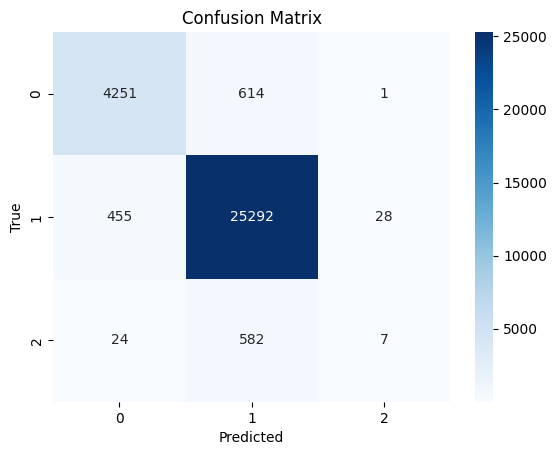

In [ ]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


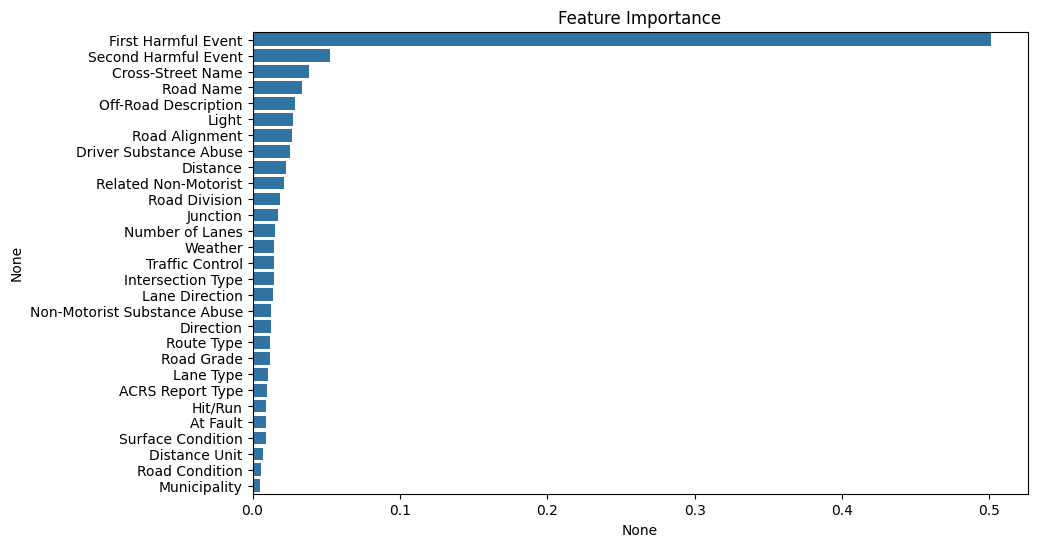

In [ ]:
# Feature Importance
importances = rf_model.feature_importances_
indices = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=indices, y=indices.index)
plt.title('Feature Importance')
plt.show()


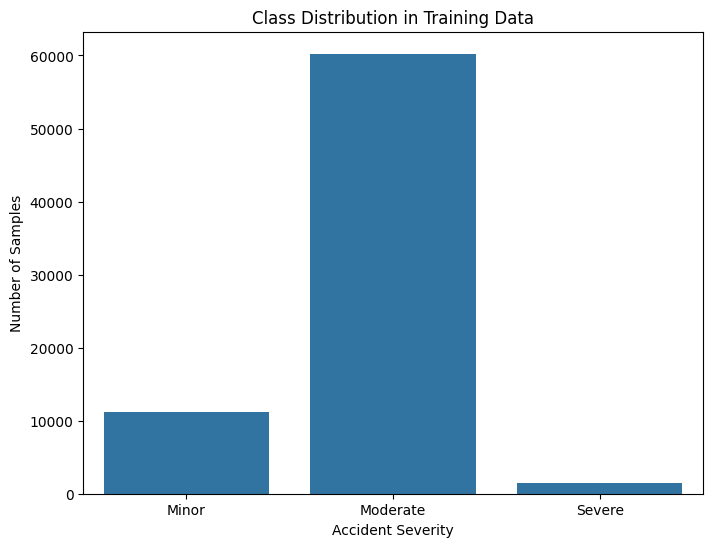

In [ ]:
import pandas as pd

# Checking the distribution of each class
class_distribution = pd.Series(y_train).value_counts().sort_index()
class_labels = ['Minor', 'Moderate', 'Severe']

plt.figure(figsize=(8, 6))
sns.barplot(x=class_labels, y=class_distribution)
plt.xlabel('Accident Severity')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Training Data')
plt.show()
